# Hardware Performance Counter Based Malware Detection

## Introduction
This notebook demonstrates how to build machine learning models that can detect malware based on Hardware Performance Counter (HPC) data. HPCs capture low-level CPU events that can reveal distinctive patterns between benign and malicious software execution.

## Data Loading and Preparation
The following cell loads the preprocessed HPC data from CSV files and prepares it for machine learning:

In [ ]:
# Now we run ML to train a model on the data using scikit learn
import os
try:
    import pandas as pd
except ImportError:
    % pip install pandas
    import pandas as pd
try:
    from sklearn.model_selection import train_test_split
except ImportError:
    % pip install scikit-learn
    from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


# Load all CSV files into a single DataFrame
def load_data_from_csvs(directory):
    all_data = []
    for fname in os.listdir(directory):
        if fname.endswith('.csv'):
            file_path = os.path.join(directory, fname)
            df = pd.read_csv(file_path)
            all_data.append(df)
    return pd.concat(all_data, ignore_index=True)

out_dir = './Data'  # Directory where the CSV files are stored
# Load the data
data = load_data_from_csvs(out_dir)

## Random Forest Classification
This section implements a Random Forest classifier to detect malware based on hardware performance counter data. Random Forests are effective for this task because they:
- Can handle high-dimensional data with many HPC features
- Are robust against outliers in the performance metrics
- Provide feature importance measures to understand which HPCs are most predictive

In [ ]:
# Separate features and target
X = data.drop(columns=['time', 'class'])
y = data['class']
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Train a Random Forest Classifier
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)
# Make predictions
y_pred = clf.predict(X_test)
# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

## XGBoost Classification
XGBoost is an advanced gradient boosting implementation that often achieves state-of-the-art results. We compare its performance to the Random Forest model to determine the most effective approach for malware detection using HPC data.

In [11]:
# Now lets use a different model, a XGBoost Classifier
try:
    from xgboost import XGBClassifier
except ImportError:
    %pip install xgboost
    from xgboost import XGBClassifier 

# Train an XGBoost Classifier
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', n_estimators=200, random_state=42)
xgb_clf.fit(X_train, y_train)
# Make predictions
y_pred_xgb = xgb_clf.predict(X_test)
# Evaluate the XGBoost model
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

/home/eng/a/axm200085/SATC/lib64/python3.9/site-packages/xgboost/core.py:158: UserWarning: [21:00:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      2211
           1       0.91      0.91      0.91      2602

    accuracy                           0.90      4813
   macro avg       0.90      0.90      0.90      4813
weighted avg       0.90      0.90      0.90      4813

XGBoost Accuracy: 0.901101184292541


## Feature Importance Analysis
Understanding which hardware performance counters are most predictive for malware detection is crucial for:
1. Optimizing future data collection
2. Reducing overhead in real-time monitoring
3. Gaining insights into malware's distinctive execution patterns

This visualization shows which HPCs have the greatest predictive power according to our Random Forest model.

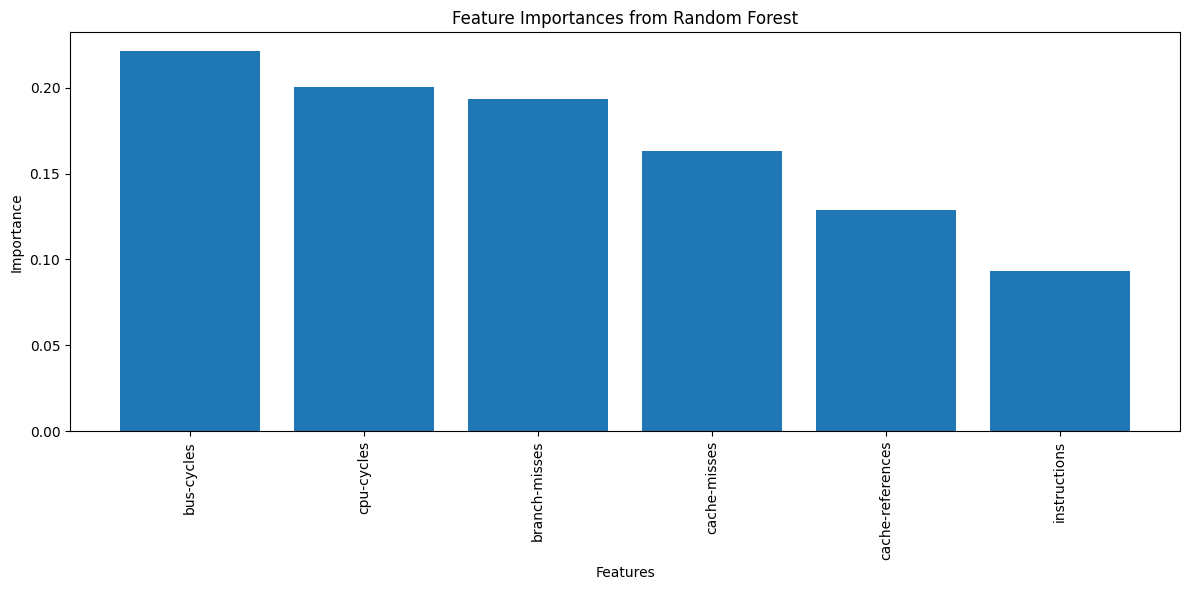

In [ ]:
# Visulalize the feature importances from the Random Forest model
try:
    import matplotlib.pyplot as plt
except ImportError:
    %pip install matplotlib
    import matplotlib.pyplot as plt
import numpy as np

# Get feature importances from the Random Forest model
importances = clf.feature_importances_
# Sort the feature importances in descending order
indices = np.argsort(importances)[::-1]
# Plot the feature importances
plt.figure(figsize=(12, 6))

plt.title("Feature Importances from Random Forest")
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()

plt.show()